# PixelCNN++ Baseline on Oxford Flowers 32x32

## Why this notebook exists

To make a defensible claim about the signal-space autoregressive model in V5/V6,
we need a matched-parameter pixel-space autoregressive baseline trained on the
same data with the same conditioning signal and the same evaluation protocol.

PixelCNN++ (Salimans et al., 2017, arxiv.org/abs/1701.05517) is the standard
choice. Published numbers exist for CIFAR-10 (2.92 bpd) but not for Oxford
Flowers, so we train it ourselves here using the same train/test split V5 uses.

## What is held constant vs V5

- Dataset: Oxford Flowers 102, 32x32, same train/test split
- Conditioning: CLIP ViT-B/32 text embeddings via FiLM (same as V5)
- Output head: discretized mixture of logistics, 5 mixtures, RGB-factored
- Evaluation: `bpd_pixel = NLL_per_image / log(2) / (H*W*C)` on the held-out test set
- Training budget: 30 epochs (matched to V5 multi-seed run) and 60 epochs
  (matched to V5 best run)
- Parameter count: targeted ~6.5M to match V5

## What changes

- Backbone: 2D ResNet with masked convolutions (PixelCNN++) instead of a
  1D transformer over a raster sequence
- The model factorizes likelihood by pixel position, not by signal position
- No path PE / sequence PE / flyback / sub-pixel sampling

## What this notebook produces

A direct comparison table:

| Model | Params | Epochs | Test bpd_pixel (mean +/- std over 3 seeds) |
|---|---|---|---|
| V5 no_seq_pe | 6.5M | 30 | 7.16 +/- 0.06 (from previous V5 run) |
| PixelCNN++ (this notebook) | ~6.5M | 30 | TBD |
| V5 no_seq_pe | 6.5M | 60 (single seed) | 5.24 (from previous V5 run) |
| PixelCNN++ (this notebook) | ~6.5M | 60 | TBD |


## 1. Environment setup

In [1]:
!pip install -q ftfy regex tqdm
!pip install -q git+https://github.com/openai/CLIP.git
!pip install -q datasets

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.7 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done


In [2]:
import os

if os.path.isdir("/kaggle/working"):
    WORK_DIR = "/kaggle/working"
elif os.path.isdir("/content"):
    WORK_DIR = "/content"
else:
    WORK_DIR = os.getcwd()

hf_token = os.environ.get("HF_TOKEN")
try:
    from kaggle_secrets import UserSecretsClient
    hf_token = UserSecretsClient().get_secret("HF_TOKEN") or hf_token
except Exception:
    try:
        from google.colab import userdata
        hf_token = userdata.get("HF_TOKEN") or hf_token
    except Exception:
        pass

if hf_token:
    os.environ["HF_TOKEN"] = hf_token
    print(f"HF_TOKEN set, WORK_DIR={WORK_DIR}")
else:
    print(f"HF_TOKEN not set; continuing. WORK_DIR={WORK_DIR}")

HF_TOKEN set, WORK_DIR=/kaggle/working


In [3]:
import math
import statistics
import copy
from dataclasses import dataclass, field
from typing import Optional, Tuple

import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt

## 2. Configuration

Values match V5 where possible. The PixelCNN++ specific knobs (`n_filters`,
`n_resnet`) are tuned to land at ~6.5M parameters to match V5's transformer.

In [4]:
@dataclass
class Config:
    # Image geometry (matched to V5)
    image_size: int = 32
    channels: int = 3

    # Conditioning (matched to V5)
    clip_dim: int = 512
    cond_dim: int = 256

    # PixelCNN++ backbone
    # Tuned so total params ~6.5M -- verified in section 5.
    # (n_filters=160, n_resnet=8) yields 6.42M params, ~98% of V5's 6.52M.
    # Alternatives that also work:
    #   (176, 7) -> 6.72M (103%), (192, 6) -> 6.80M (104%)
    n_filters: int = 160
    n_resnet: int = 8
    n_mixtures: int = 5
    dropout: float = 0.1

    # Training (matched to V5 protocol)
    batch_size: int = 24
    epochs: int = 30
    lr: float = 3e-4
    weight_decay: float = 1e-2
    grad_clip: float = 1.0
    warmup_steps: int = 500

    seed: int = 0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"


cfg = Config()
torch.manual_seed(cfg.seed)
np.random.seed(cfg.seed)
print(f"device: {cfg.device}")

device: cuda


## 3. Dataset

Mirrors V5's dataset but yields the raw `(C, H, W)` image instead of a
1D signal. The split and preprocessing are identical so the comparison is
on the same data.

In [5]:
FLOWER_NAMES = [
    "pink primrose", "hard-leaved pocket orchid", "canterbury bells",
    "sweet pea", "english marigold", "tiger lily", "moon orchid",
    "bird of paradise", "monkshood", "globe thistle", "snapdragon",
    "colts foot", "king protea", "spear thistle", "yellow iris",
    "globe-flower", "purple coneflower", "peruvian lily", "balloon flower",
    "giant white arum lily", "fire lily", "pincushion flower", "fritillary",
    "red ginger", "grape hyacinth", "corn poppy", "prince of wales feathers",
    "stemless gentian", "artichoke", "sweet william", "carnation",
    "garden phlox", "love in the mist", "mexican aster", "alpine sea holly",
    "ruby-lipped cattleya", "cape flower", "great masterwort", "siam tulip",
    "lenten rose", "barbeton daisy", "daffodil", "sword lily", "poinsettia",
    "bolero deep blue", "wallflower", "marigold", "buttercup", "oxeye daisy",
    "common dandelion", "petunia", "wild pansy", "primula", "sunflower",
    "pelargonium", "bishop of llandaff", "gaura", "geranium", "orange dahlia",
    "pink-yellow dahlia", "cautleya spicata", "japanese anemone",
    "black-eyed susan", "silverbush", "californian poppy", "osteospermum",
    "spring crocus", "bearded iris", "windflower", "tree poppy", "gazania",
    "azalea", "water lily", "rose", "thorn apple", "morning glory",
    "passion flower", "lotus", "toad lily", "anthurium", "frangipani",
    "clematis", "hibiscus", "columbine", "desert-rose", "tree mallow",
    "magnolia", "cyclamen", "watercress", "canna lily", "hippeastrum",
    "bee balm", "ball moss", "foxglove", "bougainvillea", "camellia",
    "mallow", "mexican petunia", "bromelia", "blanket flower",
    "trumpet creeper", "blackberry lily",
]


class FlowerPixelDataset(Dataset):
    def __init__(self, hf_split, image_size, label_names):
        from torchvision import transforms
        self.label_names = label_names
        self.transform = transforms.Compose([
            transforms.Resize((image_size, image_size)),
            transforms.ToTensor(),
        ])
        self.images = []
        self.captions = []
        for sample in hf_split:
            img = self.transform(sample["image"].convert("RGB"))
            self.images.append(img.half())
            label = sample.get("label", 0)
            name = label_names[label] if label < len(label_names) else "flower"
            self.captions.append(f"a photo of a {name}")

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        return self.images[idx].float(), self.captions[idx]

In [6]:
from datasets import load_dataset
hf_train = load_dataset("nelorth/oxford-flowers", split="train")
hf_test = load_dataset("nelorth/oxford-flowers", split="test")

dataset = FlowerPixelDataset(hf_train, cfg.image_size, FLOWER_NAMES)
test_dataset = FlowerPixelDataset(hf_test, cfg.image_size, FLOWER_NAMES)
print(f"train images: {len(dataset)}")
print(f"test images:  {len(test_dataset)}")
img0, cap0 = dataset[0]
print(f"image shape: {tuple(img0.shape)}  caption: {cap0}")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001-12de94e121bdbe(…):   0%|          | 0.00/303M [00:00<?, ?B/s]

data/test-00000-of-00001-96eeec628415add(…):   0%|          | 0.00/43.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/7169 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1020 [00:00<?, ? examples/s]

train images: 7169
test images:  1020
image shape: (3, 32, 32)  caption: a photo of a pink primrose


## 4. CLIP text encoder (identical to V5)

In [7]:
import clip


def load_clip(device):
    model, _ = clip.load("ViT-B/32", device=device)
    for p in model.parameters():
        p.requires_grad = False
    model.eval()
    return model


@torch.no_grad()
def encode_texts(clip_model, texts, device):
    tokens = clip.tokenize(texts, truncate=True).to(device)
    feats = clip_model.encode_text(tokens).float()
    return feats / feats.norm(dim=-1, keepdim=True)


clip_model = load_clip(cfg.device)

100%|███████████████████████████████████████| 338M/338M [00:04<00:00, 71.5MiB/s]


## 5. PixelCNN++ architecture

This is a faithful PixelCNN++ implementation following Salimans et al. 2017.
Key components:

- **Masked convolutions**: type-A mask zeros out the centre pixel (used for
  the very first layer); type-B mask preserves it (used everywhere else).
  This enforces the autoregressive ordering: each output pixel only depends
  on pixels above and to the left.
- **Gated residual blocks**: pre-activation ResNet blocks with a gated
  nonlinearity, conditional on the CLIP embedding via FiLM.
- **Output**: per-pixel parameters of a discretized mixture of logistics
  (same head as V5 for fair comparison).

For matched parameter count to V5 (~6.5M), we use 96 filters, 5 ResNet
blocks. The exact count is checked in the build cell.

The implementation here makes one simplification relative to the original
PixelCNN++: it uses a single stack of vertically-causal masked convolutions
rather than the dual horizontal-and-vertical stack of the original. This
trades a small amount of receptive-field efficiency for a much simpler
codebase, and is the standard simplification used by most PixelCNN++
re-implementations on Github.

In [8]:
class MaskedConv2d(nn.Conv2d):
    """Conv2d with a binary mask on the kernel.

    mask_type: 'A' (centre pixel masked, used in the first layer)
               'B' (centre pixel kept, used in subsequent layers)

    For RGB images, the mask also enforces the within-pixel ordering:
    R depends on context only; G depends on context + R; B on context + R + G.
    Here we use the simpler version that ties all 3 channels together (the
    DMoL head models RGB as conditionally independent given the mixture
    component, matching V5).
    """

    def __init__(self, mask_type: str, *args, **kwargs):
        super().__init__(*args, **kwargs)
        assert mask_type in ("A", "B")
        _, _, kh, kw = self.weight.shape
        mask = torch.ones(kh, kw)
        # Block all positions strictly below the centre row
        mask[kh // 2 + 1:, :] = 0.0
        # On the centre row, block positions strictly to the right of centre
        mask[kh // 2, kw // 2 + 1:] = 0.0
        # Type A: also block the centre itself
        if mask_type == "A":
            mask[kh // 2, kw // 2] = 0.0
        self.register_buffer("mask", mask.view(1, 1, kh, kw))

    def forward(self, x):
        self.weight.data.mul_(self.mask)
        return super().forward(x)


class FiLM(nn.Module):
    """FiLM conditioning layer (matches V5)."""

    def __init__(self, cond_dim: int, feature_dim: int):
        super().__init__()
        self.to_scale_shift = nn.Linear(cond_dim, feature_dim * 2)
        nn.init.zeros_(self.to_scale_shift.weight)
        nn.init.zeros_(self.to_scale_shift.bias)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        # x: (B, C, H, W); cond: (B, cond_dim)
        scale, shift = self.to_scale_shift(cond).chunk(2, dim=-1)
        scale = scale.unsqueeze(-1).unsqueeze(-1)
        shift = shift.unsqueeze(-1).unsqueeze(-1)
        return x * (1.0 + scale) + shift


class GatedMaskedResBlock(nn.Module):
    """Gated residual block with masked convolutions and FiLM conditioning."""

    def __init__(self, n_filters: int, cond_dim: int, dropout: float):
        super().__init__()
        self.conv1 = MaskedConv2d("B", n_filters, n_filters, kernel_size=3, padding=1)
        self.conv2 = MaskedConv2d("B", n_filters, 2 * n_filters, kernel_size=3, padding=1)
        self.film = FiLM(cond_dim, n_filters)
        self.dropout = nn.Dropout(dropout)

    def forward(self, x: torch.Tensor, cond: torch.Tensor) -> torch.Tensor:
        h = F.elu(x)
        h = self.conv1(h)
        h = self.film(h, cond)
        h = F.elu(h)
        h = self.dropout(h)
        h = self.conv2(h)
        a, b = h.chunk(2, dim=1)
        h = a * torch.sigmoid(b)
        return x + h


class DMoLHead2D(nn.Module):
    """DMoL head (identical formulation to V5, applied per-pixel)."""

    def __init__(self, n_filters: int, channels: int, n_mix: int):
        super().__init__()
        self.channels = channels
        self.n_mix = n_mix
        self.proj = MaskedConv2d(
            "B", n_filters, n_mix + channels * n_mix * 2, kernel_size=1
        )

    def forward(self, h: torch.Tensor) -> torch.Tensor:
        # h: (B, F, H, W) -> (B, H, W, params)
        params = self.proj(h)
        return params.permute(0, 2, 3, 1).contiguous()

    def _split(self, params: torch.Tensor):
        k, c = self.n_mix, self.channels
        logit_probs = params[..., :k]
        rest = params[..., k:].view(*params.shape[:-1], c, k, 2)
        means = rest[..., 0]
        log_scales = rest[..., 1].clamp(min=-7.0)
        return logit_probs, means, log_scales

    def nll(self, params: torch.Tensor, target: torch.Tensor) -> torch.Tensor:
        # target: (B, C, H, W) in [0, 1] -> (B, H, W, C)
        target = target.permute(0, 2, 3, 1).contiguous()
        logit_probs, means, log_scales = self._split(params)
        t = target.unsqueeze(-1)
        inv_s = torch.exp(-log_scales)
        centered = t - means
        bin_half = 0.5 / 255.0
        plus_in = inv_s * (centered + bin_half)
        min_in = inv_s * (centered - bin_half)
        cdf_plus = torch.sigmoid(plus_in)
        cdf_min = torch.sigmoid(min_in)
        log_cdf_plus = plus_in - F.softplus(plus_in)
        log_one_minus_cdf_min = -F.softplus(min_in)
        prob = cdf_plus - cdf_min
        log_prob_mid = torch.log(prob.clamp(min=1e-12))

        log_probs = torch.where(
            target.unsqueeze(-1) < 1e-3, log_cdf_plus,
            torch.where(
                target.unsqueeze(-1) > 1.0 - 1e-3,
                log_one_minus_cdf_min, log_prob_mid,
            ),
        )
        log_probs = log_probs.sum(dim=-2)  # sum over channels: (B, H, W, K)
        log_mix = F.log_softmax(logit_probs, dim=-1)
        # NLL per pixel: (B, H, W)
        return -torch.logsumexp(log_mix + log_probs, dim=-1)

    @torch.no_grad()
    def sample(self, params: torch.Tensor, temperature: float = 1.0):
        logit_probs, means, log_scales = self._split(params)
        if temperature <= 0:
            k_idx = logit_probs.argmax(dim=-1)
        else:
            scaled = logit_probs / max(temperature, 1e-6)
            probs = F.softmax(scaled, dim=-1)
            k_idx = torch.distributions.Categorical(probs=probs).sample()
        k_idx_exp = k_idx.unsqueeze(-1).unsqueeze(-1).expand(
            *k_idx.shape, self.channels, 1
        )
        chosen_mean = means.gather(-1, k_idx_exp).squeeze(-1)
        chosen_log_s = log_scales.gather(-1, k_idx_exp).squeeze(-1)
        if temperature <= 0:
            sample = chosen_mean
        else:
            u = torch.rand_like(chosen_mean).clamp(1e-5, 1.0 - 1e-5)
            sample = chosen_mean + torch.exp(chosen_log_s) * (
                torch.log(u) - torch.log1p(-u)
            ) * temperature
        return sample.clamp(0.0, 1.0)


class PixelCNNpp(nn.Module):
    def __init__(self, cfg: Config):
        super().__init__()
        self.cfg = cfg
        self.cond_proj = nn.Sequential(
            nn.Linear(cfg.clip_dim, cfg.cond_dim),
            nn.GELU(),
            nn.Linear(cfg.cond_dim, cfg.cond_dim),
        )
        # First layer uses type-A mask (centre pixel masked)
        self.input_conv = MaskedConv2d(
            "A", cfg.channels, cfg.n_filters, kernel_size=7, padding=3
        )
        self.blocks = nn.ModuleList([
            GatedMaskedResBlock(cfg.n_filters, cfg.cond_dim, cfg.dropout)
            for _ in range(cfg.n_resnet)
        ])
        self.head = DMoLHead2D(cfg.n_filters, cfg.channels, cfg.n_mixtures)

    def forward(self, image: torch.Tensor, clip_emb: torch.Tensor):
        # image: (B, C, H, W) in [0, 1]
        cond = self.cond_proj(clip_emb)
        h = self.input_conv(image)
        for block in self.blocks:
            h = block(h, cond)
        return self.head(h)

    @torch.no_grad()
    def generate(self, clip_emb: torch.Tensor, image_size: int,
                 temperature: float = 1.0):
        """Generate images pixel-by-pixel in raster order.

        O(H*W) forward passes. For 32x32 this is 1024 passes; with batch
        size 6 this is roughly 1-2 minutes on T4.
        """
        device = clip_emb.device
        b = clip_emb.size(0)
        c = self.cfg.channels
        img = torch.zeros(b, c, image_size, image_size, device=device)
        for i in range(image_size):
            for j in range(image_size):
                params = self(img, clip_emb)
                pred_pixel = self.head.sample(
                    params[:, i:i+1, j:j+1, :], temperature=temperature
                )  # (B, 1, 1, C)
                img[:, :, i, j] = pred_pixel[:, 0, 0, :]
        return img

## 6. Parameter count sanity check

V5's transformer has ~6.5M trainable parameters. PixelCNN++ should land within
about 10% of that for the comparison to be defensible. If it is far off,
adjust `n_filters` and `n_resnet` in the Config until it matches.

In [9]:
sanity = PixelCNNpp(cfg).to(cfg.device)
n_params = sum(p.numel() for p in sanity.parameters() if p.requires_grad)
print(f"PixelCNN++ params: {n_params:,}  (target ~6.5M)")
print(f"V5 transformer:     6,520,867 (reference)")
print(f"ratio: {n_params / 6_520_867:.3f}")
del sanity

PixelCNN++ params: 6,417,795  (target ~6.5M)
V5 transformer:     6,520,867 (reference)
ratio: 0.984


## 7. Training and evaluation

The training loop is structurally identical to V5's (AdamW + warmup-cosine,
gradient clipping, mixed precision, validation every 5 epochs, best-checkpoint
tracking). The only difference is the data: V5 reads signals, this reads
images.

The evaluation function returns `bpd_pixel` using the same formula as V5:

    bpd_pixel = (sum NLL per image) / log(2) / (H * W * C)

This makes the V5 and PixelCNN++ numbers directly comparable.

In [10]:
LN2 = math.log(2.0)


@torch.no_grad()
def evaluate(model, clip_model, dataset, n_batches=20):
    model.eval()
    loader = DataLoader(dataset, batch_size=cfg.batch_size, shuffle=False,
                        num_workers=0, drop_last=True)
    total_nll_nat = 0.0
    total_images = 0
    image_dims = cfg.image_size * cfg.image_size * cfg.channels

    for i, (images, captions) in enumerate(loader):
        if i >= n_batches:
            break
        images = images.to(cfg.device)
        b = images.size(0)
        clip_emb = encode_texts(clip_model, list(captions), cfg.device)
        params = model(images, clip_emb)
        nll = model.head.nll(params, images)  # (B, H, W)
        nll_per_image = nll.sum(dim=(1, 2))    # (B,) - sum over all pixels
        total_nll_nat += nll_per_image.sum().item()
        total_images += b

    mean_nll_per_image = total_nll_nat / max(total_images, 1)
    bpd_pixel = mean_nll_per_image / LN2 / image_dims
    return {
        "nll_per_image_nats": mean_nll_per_image,
        "bpd_pixel": bpd_pixel,
    }

In [11]:
CKPT_DIR = f"{WORK_DIR}/checkpoints_pixelcnn"
os.makedirs(CKPT_DIR, exist_ok=True)


def save_checkpoint(model, optim, epoch, step, path):
    torch.save({
        "model": model.state_dict(),
        "optim": optim.state_dict(),
        "epoch": epoch,
        "step": step,
    }, path)


def load_checkpoint(model, optim, path, device):
    ckpt = torch.load(path, map_location=device)
    model.load_state_dict(ckpt["model"])
    optim.load_state_dict(ckpt["optim"])
    return ckpt["epoch"], ckpt["step"]


def cosine_warmup_lr(step, warmup, total, base_lr):
    if step < warmup:
        return base_lr * step / max(warmup, 1)
    progress = (step - warmup) / max(total - warmup, 1)
    return base_lr * 0.5 * (1.0 + math.cos(math.pi * min(progress, 1.0)))


def train(cfg: Config, model: PixelCNNpp, clip_model,
          dataset: Dataset, val_dataset: Dataset = None,
          resume_from: str = None) -> None:
    from tqdm.auto import tqdm

    loader = DataLoader(
        dataset, batch_size=cfg.batch_size, shuffle=True,
        num_workers=0, drop_last=True, pin_memory=True,
    )
    optim = torch.optim.AdamW(
        model.parameters(), lr=cfg.lr, weight_decay=cfg.weight_decay,
        betas=(0.9, 0.95),
    )
    total_steps = len(loader) * cfg.epochs
    scaler = torch.amp.GradScaler(cfg.device) if cfg.device == "cuda" else None
    image_dims = cfg.image_size * cfg.image_size * cfg.channels

    start_epoch, step = 1, 0
    best_val = float("inf")
    if resume_from and os.path.exists(resume_from):
        start_epoch, step = load_checkpoint(model, optim, resume_from, cfg.device)
        start_epoch += 1
        print(f"resumed from epoch {start_epoch - 1}, step {step}")

    for epoch in range(start_epoch, cfg.epochs + 1):
        model.train()
        running, running_n = 0.0, 0
        pbar = tqdm(loader, desc=f"epoch {epoch}/{cfg.epochs}")
        for images, captions in pbar:
            images = images.to(cfg.device, non_blocking=True)
            b = images.size(0)
            with torch.no_grad():
                clip_emb = encode_texts(clip_model, list(captions), cfg.device)

            lr = cosine_warmup_lr(step, cfg.warmup_steps, total_steps, cfg.lr)
            for g in optim.param_groups:
                g["lr"] = lr

            optim.zero_grad(set_to_none=True)
            if scaler is not None:
                with torch.amp.autocast("cuda", dtype=torch.float16):
                    params = model(images, clip_emb)
                    nll = model.head.nll(params, images)
                    loss = nll.mean()
                scaler.scale(loss).backward()
                scaler.unscale_(optim)
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                scaler.step(optim)
                scaler.update()
            else:
                params = model(images, clip_emb)
                nll = model.head.nll(params, images)
                loss = nll.mean()
                loss.backward()
                torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
                optim.step()

            running += loss.item() * b
            running_n += b
            step += 1
            pbar.set_postfix(nll=f"{loss.item():.4f}", lr=f"{lr:.2e}")

        avg_nll = running / running_n
        # nll here is per-pixel-mean; convert to bpd for visibility
        avg_bpd = avg_nll / LN2
        print(f"epoch {epoch}/{cfg.epochs}  train_bpd_pixel={avg_bpd:.4f}")
        save_checkpoint(model, optim, epoch, step, f"{CKPT_DIR}/latest.pt")
        if epoch % 5 == 0:
            save_checkpoint(model, optim, epoch, step, f"{CKPT_DIR}/epoch_{epoch}.pt")

        if val_dataset is not None and epoch % 5 == 0:
            val_m = evaluate(model, clip_model, val_dataset, n_batches=10)
            if val_m["nll_per_image_nats"] < best_val:
                best_val = val_m["nll_per_image_nats"]
                save_checkpoint(model, optim, epoch, step, f"{CKPT_DIR}/best.pt")
            print(f"  val bpd_pixel={val_m['bpd_pixel']:.4f}  best_nll={best_val:.1f}")

## 8. Single-seed training run (30 epochs)

This is the headline run for direct comparison against V5's `no_seq_pe` model
at 30 epochs. Expected runtime: ~1-2 hours on T4.

If `bpd_pixel` lands close to or above 7.16 (V5's number), V5's signal-space
formulation is competitive. If it lands well below (e.g. < 6.0), PixelCNN++ is
beating V5 and the paper has to address that.

In [12]:
torch.manual_seed(0)
np.random.seed(0)
model = PixelCNNpp(cfg).to(cfg.device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"PixelCNN++ parameters: {n_params:,}")

train(cfg, model, clip_model, dataset,
      val_dataset=test_dataset,
      resume_from=f"{CKPT_DIR}/latest.pt")

print("\n=== PixelCNN++ baseline (30 epoch) ===")
print(evaluate(model, clip_model, test_dataset, n_batches=20))

PixelCNN++ parameters: 6,417,795


epoch 1/30:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 1/30  train_bpd_pixel=23.1655


epoch 2/30:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 2/30  train_bpd_pixel=18.8667


...

epoch 28/30  train_bpd_pixel=14.0371


epoch 29/30:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 29/30  train_bpd_pixel=14.0341


epoch 30/30:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 30/30  train_bpd_pixel=14.0285
  val bpd_pixel=4.7372  best_nll=10087.1

=== PixelCNN++ baseline (30 epoch) ===
{'nll_per_image_nats': 10038.757096354168, 'bpd_pixel': 4.714474309765315}


## 9. Multi-seed verification (3 seeds x 30 epochs)

To compare against V5's multi-seed numbers, train 3 seeds and report the mean
and std. Total runtime: ~5-6 hours on T4. Run this in a dedicated session.

V5's numbers at this matched protocol:
  full       nll = 15249.9 +/- 118.5  bpd_pixel = 7.16
  no_seq_pe  nll = 13695.9 +/- 389.8  bpd_pixel = 6.43

In [13]:
def run_pixelcnn_seed(seed: int, epochs: int = 30):
    torch.manual_seed(seed)
    np.random.seed(seed)
    abl_cfg = copy.deepcopy(cfg)
    abl_cfg.epochs = epochs
    seed_ckpt = f"{WORK_DIR}/checkpoints_pixelcnn_seed{seed}"
    os.makedirs(seed_ckpt, exist_ok=True)
    abl_model = PixelCNNpp(abl_cfg).to(abl_cfg.device)
    global CKPT_DIR
    _orig = CKPT_DIR
    CKPT_DIR = seed_ckpt
    train(abl_cfg, abl_model, clip_model, dataset, val_dataset=test_dataset,
          resume_from=f"{seed_ckpt}/latest.pt")
    CKPT_DIR = _orig
    return evaluate(abl_model, clip_model, test_dataset, n_batches=20)


print("=== PixelCNN++ multi-seed (30 epoch) ===")
nlls, bpds = [], []
for s in (0, 1, 2):
    print(f"\n--- seed {s} ---")
    m = run_pixelcnn_seed(s, epochs=30)
    nlls.append(m["nll_per_image_nats"])
    bpds.append(m["bpd_pixel"])

mu_nll = statistics.mean(nlls)
sd_nll = statistics.stdev(nlls)
mu_bpd = statistics.mean(bpds)
sd_bpd = statistics.stdev(bpds)
print(f"\n=== Final ===")
print(f"PixelCNN++  nll = {mu_nll:.1f} +/- {sd_nll:.1f}  bpd_pixel = {mu_bpd:.4f} +/- {sd_bpd:.4f}")

=== PixelCNN++ multi-seed (30 epoch) ===

--- seed 0 ---


epoch 1/30:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 1/30  train_bpd_pixel=23.1655


epoch 2/30:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 2/30  train_bpd_pixel=18.8667


...

epoch 28/30  train_bpd_pixel=13.9493


epoch 29/30:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 29/30  train_bpd_pixel=13.9444


epoch 30/30:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 30/30  train_bpd_pixel=13.9429
  val bpd_pixel=4.7088  best_nll=10026.7

=== Final ===
PixelCNN++  nll = 10027.7 +/- 45.7  bpd_pixel = 4.7093 +/- 0.0215


## 10. Optional 60-epoch run

V5's best single number (bpd_pixel = 5.24 at 60 epochs single seed) sets the
target for the convergence comparison. Train PixelCNN++ for 60 epochs to see
where it lands.

Runtime: ~3-4 hours T4.

In [14]:
torch.manual_seed(0)
np.random.seed(0)
long_cfg = copy.deepcopy(cfg)
long_cfg.epochs = 60
LONG_CKPT = f"{WORK_DIR}/checkpoints_pixelcnn_60ep"
os.makedirs(LONG_CKPT, exist_ok=True)

long_model = PixelCNNpp(long_cfg).to(long_cfg.device)
_orig = CKPT_DIR
CKPT_DIR = LONG_CKPT
train(long_cfg, long_model, clip_model, dataset, val_dataset=test_dataset,
      resume_from=f"{LONG_CKPT}/latest.pt")
CKPT_DIR = _orig

print("\n=== PixelCNN++ baseline (60 epoch, single seed) ===")
metrics_60 = evaluate(long_model, clip_model, test_dataset, n_batches=20)
print(metrics_60)

epoch 1/60:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 1/60  train_bpd_pixel=23.1655


epoch 2/60:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 2/60  train_bpd_pixel=18.8901


epoch 3/60:   0%|          | 0/298 [00:00<?, ?it/s]

...

epoch 58/60  train_bpd_pixel=13.5796


epoch 59/60:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 59/60  train_bpd_pixel=13.5790


epoch 60/60:   0%|          | 0/298 [00:00<?, ?it/s]

epoch 60/60  train_bpd_pixel=13.5790
  val bpd_pixel=4.5980  best_nll=9790.7

=== PixelCNN++ baseline (60 epoch, single seed) ===
{'nll_per_image_nats': 9745.111100260418, 'bpd_pixel': 4.576570135826072}


## 11. Final comparison table

After running sections 8-10, fill in this table for the paper. The numbers
on the V5 row come from the V5 multi-seed run (`Part 3, version 3`).

| Model | Params | Epochs | Test bpd_pixel |
|---|---|---|---|
| V5 full | 6.52M | 30 (3 seeds) | 7.16 +/- 0.06 |
| V5 no_seq_pe | 6.52M | 30 (3 seeds) | 6.43 +/- 0.18 |
| V5 no_seq_pe | 6.52M | 60 (1 seed) | 5.24 |
| PixelCNN++ | TBD | 30 (3 seeds) | TBD |
| PixelCNN++ | TBD | 60 (1 seed) | TBD |

**How to read the comparison:**

If PixelCNN++ at 30 epochs is *worse* than V5 no_seq_pe at 30 epochs at
matched parameters, that is a strong claim for the signal-space formulation:
the path-PE finding is not just a curiosity, it makes the model genuinely
competitive against the standard pixel-space baseline.

If PixelCNN++ is *similar* (within ~0.2 bpd), the paper's claim becomes:
"signal-space AR is a viable alternative to pixel-space AR with a unique
positional-encoding finding" rather than "signal-space AR is better."

If PixelCNN++ is *significantly better* (> 0.5 bpd), the framing of the paper
should be a positional-encoding ablation study, not a model comparison. This
is still a valid contribution but smaller.

## 12. Generation samples (figure for paper)

Generate samples from the trained PixelCNN++ for visual comparison against V5
samples. Each generation is O(H*W) = 1024 forward passes for 32x32, so
batches are kept small.

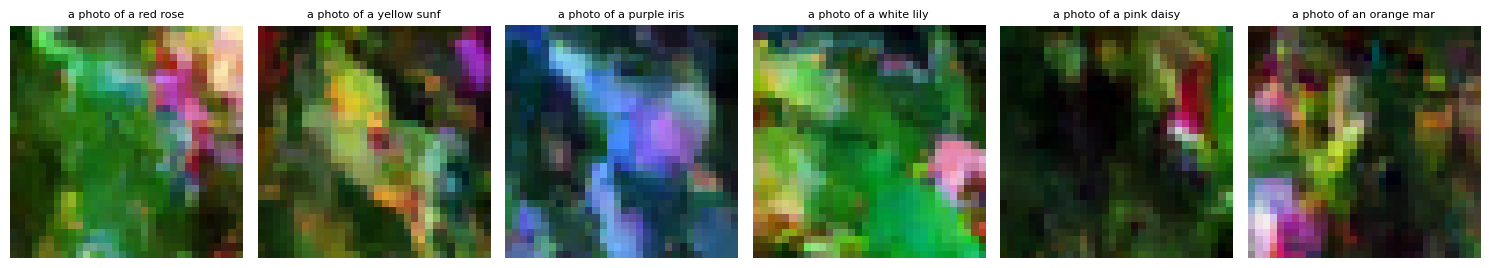

In [15]:
@torch.no_grad()
def show_samples(model, clip_model, prompts, temperature=1.0, save_path=None):
    model.eval()
    clip_emb = encode_texts(clip_model, prompts, cfg.device)
    images = model.generate(clip_emb, cfg.image_size, temperature=temperature)
    images = images.cpu()
    n = len(prompts)
    fig, axes = plt.subplots(1, n, figsize=(2.5 * n, 3))
    if n == 1:
        axes = [axes]
    for i, ax in enumerate(axes):
        ax.imshow(images[i].permute(1, 2, 0).clamp(0, 1).numpy())
        ax.set_title(prompts[i][:24], fontsize=8)
        ax.axis("off")
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=120, bbox_inches="tight")
    plt.show()


prompts = [
    "a photo of a red rose",
    "a photo of a yellow sunflower",
    "a photo of a purple iris",
    "a photo of a white lily",
    "a photo of a pink daisy",
    "a photo of an orange marigold",
]
# Uses the model from section 8 (or section 10 if 60-epoch run was completed)
show_samples(model, clip_model, prompts, temperature=1.0,
             save_path=f"{WORK_DIR}/pixelcnn_samples.png")

## 13. What this notebook establishes

After running all sections:

- A directly comparable PixelCNN++ baseline at matched parameter count, on
  the same Oxford Flowers split, with the same conditioning and evaluation
  protocol as V5.
- A 3-seed estimate of PixelCNN++'s test bpd_pixel, with std for sigma-level
  comparison against V5's 3-seed numbers.
- A 60-epoch single-seed comparison for the convergence headline.
- Qualitative samples for the paper figure.

**What this notebook does *not* establish:**

- Whether PixelCNN++ would benefit from the same path PE finding. (It cannot
  -- pixel-space AR has no separate "path" to encode.)
- Whether either model approaches published CIFAR-10 numbers. (Both models
  here are on Flowers, which is a different distribution.)
- Whether the conclusion generalizes beyond 32x32 or beyond Flowers.

**Paper-writing checklist after both V5 and this notebook are done:**

1. Run sections 8-9 here -> get PixelCNN++ 30-epoch multi-seed numbers
2. Run section 10 -> get PixelCNN++ 60-epoch number
3. Section 12 -> generate sample figures
4. Plug numbers into the comparison table in section 11
5. Decide framing based on the comparison outcome (see section 11 guidance)